In [1]:
"""Economic characterisation of the identified market regimes.

Paired script for notebooks/regime_characterization.ipynb.
"""

'Economic characterisation of the identified market regimes.\n\nPaired script for notebooks/regime_characterization.ipynb.\n'

# What the identified regimes correspond to

Reviewer 3 asks for "a time series plot highlighting or comparing how the
forecasted regime differ from NBER recession and documented Daniel & Moskowitz
(2016) momentum-crash dates".

The regimes are estimated from factor returns alone, with no macroeconomic input
of any kind. Whether they line up with independently dated recessions and
momentum crashes is therefore a genuine out-of-model check rather than a
restatement of how they were constructed.

Momentum crashes are identified **empirically**, as the worst months of the UMD
factor over the sample, rather than by transcribing a list. The episodes that
emerge are then compared with those documented by Daniel and Moskowitz (2016).
Selecting them from the data avoids any suggestion that the dates were chosen to
flatter the regime classification.

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

from regimeaware.constants import (
    HISTORY_END_DT,
    HISTORY_START_DT,
    DataConstants,
    Factors,
)

plt.rcParams.update(
    {"text.usetex": True, "font.family": "serif", "font.sans-serif": ["CMU Serif"]}
)

## 1. Data and fitted model

The sample is pinned to the period the paper reports. This matters: the cached
factor file now extends beyond it, and `routines/distributions.py` does not
truncate, so an unpinned re-run would silently fit a longer sample than the one
described in the text.

In [3]:
mdl = pd.read_pickle(f"{DataConstants.WDIR.value}/data/dist/mdl_hmm.pkl")

factors = Factors._member_names_
ff = pd.read_pickle(f"{DataConstants.WDIR.value}/data/ff.pkl")
ff = ff.loc[HISTORY_START_DT:HISTORY_END_DT]
X = ff[factors]

print(f"sample: {X.index.min():%Y-%m} to {X.index.max():%Y-%m}  ({len(X)} months)")

probs = pd.DataFrame(
    mdl.predict_proba(X.values), index=X.index, columns=range(mdl.n_components)
)

# Order the states by their market risk premium so the labels are stable and
# economically interpretable rather than an artefact of the EM starting point.
order = np.argsort(-mdl.means_[:, factors.index("mktrf")])
umd_by_state = mdl.means_[:, factors.index("umd")]

NAMES = {}
for rank, state in enumerate(order):
    if umd_by_state[state] < -0.01:
        NAMES[state] = "Reversal"
    elif mdl.means_[state, factors.index("mktrf")] < 0:
        NAMES[state] = "Bear"
    else:
        NAMES[state] = "Bull"

probs.columns = [NAMES[c] for c in probs.columns]
probs = probs[["Bull", "Reversal", "Bear"]]
modal = probs.idxmax(axis=1)

print("\nstate labelling:", NAMES)
print("\nunconditional occupancy (%):")
print((modal.value_counts(normalize=True) * 100).round(1).to_string())

sample: 1963-07 to 2024-12  (738 months)

state labelling: {np.int64(1): 'Reversal', np.int64(0): 'Bull', np.int64(2): 'Bear'}

unconditional occupancy (%):
Bull        73.7
Bear        18.8
Reversal     7.5


## 2. Independently dated events

Recession dates are read from FRED rather than transcribed, so the comparison
cannot drift from the official chronology and needs no maintenance when the
committee dates a new cycle. `USREC` marks the month **following** the peak
through the trough inclusive: under the NBER convention the peak month is the
last month of the expansion, not the first month of the contraction.

Momentum crashes are the worst 1% of UMD months in the sample.

In [4]:
def load_usrec(index):
    """NBER-based recession indicator, aligned to the factor sample."""
    cache = f"{DataConstants.WDIR.value}/data/usrec.pkl"
    try:
        import pandas_datareader.data as web

        usrec = web.DataReader(
            "USREC", "fred", index.min() - pd.DateOffset(years=1), index.max()
        )["USREC"]
        usrec.to_pickle(cache)
    except Exception as exc:  # offline: fall back on the last retrieved copy
        if not os.path.exists(cache):
            raise
        print(f"FRED unavailable ({type(exc).__name__}), using cached USREC")
        usrec = pd.read_pickle(cache)

    usrec.index = usrec.index.to_period("M")
    return usrec.reindex(index.to_period("M")).fillna(0).astype(bool).set_axis(index)


recession = load_usrec(X.index)

crash_cutoff = ff["umd"].quantile(0.01)
crashes = ff.index[ff["umd"] <= crash_cutoff]

print(f"recession months: {recession.sum()} of {len(recession)} "
      f"({recession.mean():.1%})")
print(f"\nmomentum crashes (UMD <= {crash_cutoff:.1%}):")
print((ff.loc[crashes, "umd"] * 100).round(1).to_string())

recession months: 85 of 738 (11.5%)

momentum crashes (UMD <= -11.8%):
date
1975-01-31   -13.8
2001-01-31   -25.4
2002-11-30   -16.4
2009-03-31   -11.8
2009-04-30   -34.4
2009-05-31   -12.5
2020-11-30   -12.6
2023-01-31   -16.2


## 3. Do the regimes line up?

The regimes carry no macroeconomic information, so any correspondence is
informative about what the factor structure alone reveals.

In [5]:
rows = {}
for name in ["Bull", "Reversal", "Bear"]:
    p = probs[name]
    rows[name] = {
        "Mean prob., recession": p[recession].mean(),
        "Mean prob., expansion": p[~recession].mean(),
        "Ratio": p[recession].mean() / p[~recession].mean(),
        "Mean prob., crash months": p.reindex(crashes).mean(),
        "Modal share, recession": (modal[recession] == name).mean(),
        "Modal share, crash months": (modal.reindex(crashes) == name).mean(),
    }

alignment = pd.DataFrame(rows).T
print(alignment.round(3).to_string())

          Mean prob., recession  Mean prob., expansion  Ratio  Mean prob., crash months  Modal share, recession  Modal share, crash months
Bull                      0.350                  0.767  0.455                     0.000                   0.365                        0.0
Reversal                  0.179                  0.067  2.655                     0.993                   0.165                        1.0
Bear                      0.471                  0.165  2.856                     0.007                   0.471                        0.0


### How much of this is mechanical?

The two correspondences are not equally strong as evidence, and the difference
should be stated rather than left for a referee to point out.

The *Reversal* regime carries a large negative mean on UMD and by far the widest
UMD dispersion of the three states. A month in which momentum loses a third of
its value is therefore far more likely under that state than under either other,
so classifying the worst UMD months into it is partly definitional. What is not
definitional is that a distinct state with this signature is selected at all --
the number of states was chosen by BIC on the joint six-factor distribution,
with no momentum criterion imposed -- that it turns out to be short-lived and to
act as a bridge out of stress, and that the *same* state is elevated during NBER
recessions, which the momentum factor alone would not tell you.

The *Bear* correspondence with NBER dates carries more weight, because nothing
in the estimation sees macroeconomic data. The regimes are fitted to factor
returns only, and the business cycle dates are assigned by a committee working
from output, employment and income series.

## 4. Does the regime lead or lag the NBER dating?

The NBER dates cycles retrospectively, often with a delay of many months, while
the regime probabilities are available in real time. Comparing the two at
various leads shows whether the factor structure identifies stress before it is
officially recognised.

In [6]:
lead_rows = {}
for lead in range(-6, 7):
    aligned = recession.shift(-lead).fillna(False).astype(bool)
    lead_rows[lead] = {
        "P(Bear) in recession": probs["Bear"][aligned].mean(),
        "P(Bear) elsewhere": probs["Bear"][~aligned].mean(),
    }

leads = pd.DataFrame(lead_rows).T
leads["Ratio"] = leads.iloc[:, 0] / leads.iloc[:, 1]
leads.index.name = "regime leads NBER by (months)"
print(leads.round(3).to_string())
print(f"\nstrongest correspondence at a lead of {leads['Ratio'].idxmax()} months")

                               P(Bear) in recession  P(Bear) elsewhere  Ratio
regime leads NBER by (months)                                                
-6                                            0.309              0.186  1.659
-5                                            0.331              0.183  1.802
-4                                            0.339              0.182  1.859
-3                                            0.355              0.180  1.969
-2                                            0.368              0.179  2.060
-1                                            0.403              0.174  2.318
 0                                            0.471              0.165  2.856
 1                                            0.522              0.159  3.292
 2                                            0.538              0.156  3.436
 3                                            0.525              0.158  3.320
 4                                            0.513             

C:\Users\franc\AppData\Local\Temp\ipykernel_45144\2676774371.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aligned = recession.shift(-lead).fillna(False).astype(bool)
C:\Users\franc\AppData\Local\Temp\ipykernel_45144\2676774371.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aligned = recession.shift(-lead).fillna(False).astype(bool)
C:\Users\franc\AppData\Local\Temp\ipykernel_45144\2676774371.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_obje

## 5. Regime persistence

The transition matrix implies an expected duration of $1/(1-\pi_{ss})$ months in
each state. Comparing that with the realised runs of the modal regime checks
that the fitted dynamics describe the sample rather than merely fitting it.

In [7]:
runs = (modal != modal.shift()).cumsum()
realised = modal.groupby(runs).agg(["first", "size"])

dur = {}
for state, name in NAMES.items():
    dur[name] = {
        "Implied duration (months)": 1 / (1 - mdl.transmat_[state, state]),
        "Realised mean run": realised.loc[realised["first"] == name, "size"].mean(),
        "Realised longest run": realised.loc[realised["first"] == name, "size"].max(),
        "Number of episodes": (realised["first"] == name).sum(),
    }

print(pd.DataFrame(dur).T[
    ["Implied duration (months)", "Realised mean run", "Realised longest run",
     "Number of episodes"]
].round(2).to_string())

          Implied duration (months)  Realised mean run  Realised longest run  Number of episodes
Reversal                       1.30               1.31                   3.0                42.0
Bull                           7.87               8.37                  41.0                65.0
Bear                           2.20               2.24                   9.0                62.0


## 6. Momentum crashes in event time

Averaging the *Reversal* probability over a window centred on each crash shows
how sharply the state arrives and how quickly it decays, which a calendar plot
of the full sample cannot: the eight crash months are scattered across sixty
years and each occupies a fraction of a millimetre of the time axis.

In [8]:
def event_study(series, dates, window):
    """Regime probability in the months around each dated event, by episode."""
    loc = X.index.get_indexer([pd.Timestamp(d) for d in dates], method="nearest")
    panel = {}
    for j, l in enumerate(loc):
        if l - window < 0 or l + window + 1 > len(series):
            continue
        panel[dates[j]] = series.values[l - window: l + window + 1]
    return pd.DataFrame(panel, index=range(-window, window + 1))


crash_window = event_study(probs["Reversal"], list(crashes), 6)
crash_uncond = probs["Reversal"].drop(crashes).mean()

print(f"unconditional P(Reversal) outside crash months: {crash_uncond:.3f}")
print(f"\nmean P(Reversal) in event time ({crash_window.shape[1]} episodes):")
print(crash_window.mean(axis=1).round(3).to_string())

unconditional P(Reversal) outside crash months: 0.070

mean P(Reversal) in event time (8 episodes):
-6    0.194
-5    0.070
-4    0.035
-3    0.175
-2    0.127
-1    0.359
0     0.993
1     0.341
2     0.264
3     0.209
4     0.162
5     0.192
6     0.141


## 7. The figure

Panel A abandons the probability axis altogether. Plotting a monthly
probability that moves between zero and one, for a state whose implied mean
duration is barely two months, produces a picket fence that no amount of
restyling repairs: at sixty years across a single text width there are roughly
nine months to a tenth of an inch. Encoding the modal regime as a shaded strip
keeps every month exactly as classified while letting the eye read the
clustering, which is the whole of the claim. The recession indicator sits
directly beneath on a shared axis so the comparison is a vertical glance.

Panel B carries the momentum-crash correspondence, which the calendar view
cannot show for the reason given above.

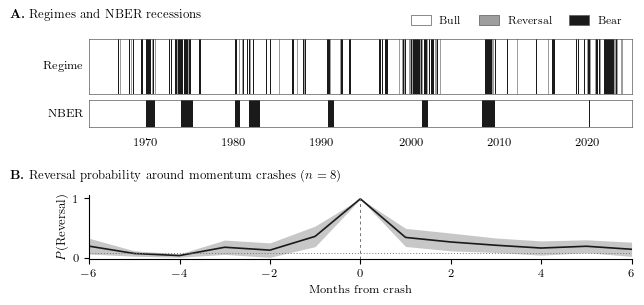

In [9]:
SHADE = {"Bull": "1.0", "Reversal": "0.62", "Bear": "0.10"}

fig = plt.figure(figsize=(7, 2.85))
outer = fig.add_gridspec(2, 1, height_ratios=[1.25, 0.9], hspace=0.9)
top = outer[0].subgridspec(2, 1, height_ratios=[1.0, 0.5], hspace=0.15)
ax_ribbon = fig.add_subplot(top[0])
ax_nber = fig.add_subplot(top[1])
ax_event = fig.add_subplot(outer[1])

# Month boundaries, so a one-month episode occupies exactly one month of the
# axis rather than being centred on the observation date.
starts = mdates.date2num(X.index.to_period("M").to_timestamp())
month = np.append(np.diff(starts), 31.0)


def runs_of(mask):
    """Contiguous (start, width) spans of a boolean month mask."""
    spans, i = [], 0
    m = np.asarray(mask)
    while i < len(m):
        if m[i]:
            j = i
            while j + 1 < len(m) and m[j + 1]:
                j += 1
            spans.append((starts[i], starts[j] + month[j] - starts[i]))
            i = j + 1
        else:
            i += 1
    return spans


# Bull is left as the background rather than shaded: it holds three quarters of
# the sample, and drawing it would leave the two states of interest as marks on
# a grey wash instead of on white.
for name in ["Reversal", "Bear"]:
    ax_ribbon.broken_barh(
        runs_of((modal == name).values), (0, 1),
        facecolor=SHADE[name], linewidth=0, antialiased=False,
    )
ax_ribbon.set_ylabel("Regime", rotation=0, ha="right", va="center", fontsize=8.5)
ax_ribbon.legend(
    handles=[Patch(facecolor=SHADE[n], edgecolor="0.35", lw=0.5, label=n)
             for n in ["Bull", "Reversal", "Bear"]],
    ncol=3, loc="lower right", bbox_to_anchor=(1, 1.06), frameon=False,
    fontsize=8, handlelength=1.8, handleheight=0.9, columnspacing=1.6,
)

ax_nber.broken_barh(
    runs_of(recession.values), (0, 1),
    facecolor="0.10", linewidth=0, antialiased=False,
)
ax_nber.set_ylabel("NBER", rotation=0, ha="right", va="center", fontsize=8.5)

for ax in [ax_ribbon, ax_nber]:
    ax.set_xlim(starts[0], starts[-1] + month[-1])
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    for side in ax.spines:
        ax.spines[side].set_linewidth(0.5)
        ax.spines[side].set_color("0.35")

ax_ribbon.tick_params(labelbottom=False)
ax_nber.xaxis.set_major_locator(mdates.YearLocator(10))
ax_nber.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_nber.tick_params(labelsize=8.5)

mean_path = crash_window.mean(axis=1)
se_path = crash_window.std(axis=1) / np.sqrt(crash_window.shape[1])

ax_event.fill_between(crash_window.index, mean_path - se_path,
                      mean_path + se_path, color="0.78", lw=0)
ax_event.plot(crash_window.index, mean_path, color="0.10", lw=1.2)
ax_event.axvline(0, color="0.45", lw=0.7, ls=(0, (3, 3)))
ax_event.axhline(crash_uncond, color="0.45", lw=0.7, ls=(0, (1, 2)))
ax_event.set_xlim(crash_window.index[0], crash_window.index[-1])
ax_event.set_ylim(-0.02, 1.05)
ax_event.set_xticks(range(-6, 7, 2))
ax_event.set_xlabel("Months from crash", fontsize=8.5)
ax_event.set_ylabel(r"$P(\mathrm{Reversal})$", fontsize=9)
ax_event.tick_params(labelsize=8.5)
for side in ["top", "right"]:
    ax_event.spines[side].set_visible(False)

fig.text(0.012, 0.985, r"\textbf{A.} Regimes and NBER recessions",
         fontsize=9, va="top")
fig.text(0.012, ax_event.get_position().y1 + 0.05,
         r"\textbf{B.} Reversal probability around momentum crashes"
         f" ($n={crash_window.shape[1]}$)", fontsize=9, va="bottom")

plt.savefig(f"{DataConstants.WDIR.value}/img/regime_timeline.pdf", dpi=300,
            transparent=True, bbox_inches="tight")
plt.show()